# PPO Implementation for Applied Project 1: Deep RL

In this notebook we will implement the Proximal Policy Optimzation (PPO) for low-dimensional OpenAI Gym environments.

PPO will be evaluated on:

- `CartPole-v1` for discrete control,
- `Acrobat-v1` for discrete control,
- `Pendulum-v1` for continuous control.

In [1]:
# If needed:
# !pip install gymnasium[classical-control] pandas

import os
import json
import pickle
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical, Normal

try:
    import gymnasium as gym
    GYMNASIUM = True
except ImportError:
    import gym
    GYMNASIUM = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Using gymnasium:", GYMNASIUM)


Using device: cuda
Using gymnasium: True


# PPO Idea

PPO is an on-policy actor-critic algorithm.

At each iteration, the current policy collects a batch of trajectories. PPO then updates the policy for several epochs using the same batch, but the key idea is the it uses clipping to stop the new policy from moving too far away from the old policiy by using the probability ratio.

The main clipped surrogate objective is:

$$
L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left(r_t(\theta)\hat{A}_t,\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]
$$

where:

$$
r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}
$$

In implementation, we minimize the negative of this objective.

# Setting up environment

In [2]:
@dataclass
class PPOConfig:
    # Training budget counts total environment interactions across all actors.
    total_steps: int = 100_000

    # PPO paper-style rollout collection: num_envs actors each collect rollout_steps transitions.
    rollout_steps: int = 512
    num_envs: int = 4

    # Evaluation
    eval_interval: int = 5_000
    eval_episodes: int = 10

    # Return/advantage estimation
    gamma: float = 0.99
    gae_lambda: float = 0.95

    # Optimization
    lr: float = 2.5e-4
    anneal_lr: bool = True
    num_epochs: int = 10
    minibatch_size: int = 256

    # PPO clipped objective
    clip_epsilon: float = 0.2
    clip_value_loss: bool = False
    value_coef: float = 0.5
    entropy_coef: float = 0.0
    max_grad_norm: float = 0.5
    target_kl: Optional[float] = None

    # Network
    hidden_dim: int = 64
    activation: str = "tanh"
    separate_actor_critic: bool = True


In [3]:
ENVIRONMENTS = {
    "cartpole": "CartPole-v1",
    "mountaincar": "MountainCar-v0",
    "mountaincar_continuous": "MountainCarContinuous-v0",
    "acrobot": "Acrobot-v1",
    "pendulum": "Pendulum-v1",
}

ALGORITHM_NAME = "PPO"
RESULTS_DIR = Path("results") / ALGORITHM_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def reset_env(env, seed=None):
    """Works with both gym and gymnasium. Always returns only the observation."""
    reset_out = env.reset(seed=seed) if seed is not None else env.reset()

    if isinstance(reset_out, tuple):
        obs, info = reset_out
    else:
        obs = reset_out

    return np.asarray(obs, dtype=np.float32)

def step_env(env, action):
    """Works with both gym and gymnasium. Always returns obs, reward, done, info."""
    step_out = env.step(action)

    if len(step_out) == 5:
        obs, reward, terminated, truncated, info = step_out
        info = dict(info)
    else:
        obs, reward, done, info = step_out
        info = dict(info)
        truncated = bool(info.get("TimeLimit.truncated", False))
        terminated = bool(done and not truncated)

    done = bool(terminated or truncated)
    info["terminated"] = bool(terminated)
    info["truncated"] = bool(truncated)

    return np.asarray(obs, dtype=np.float32), float(reward), done, info

def make_env(env_name: str, seed: int):
    env = gym.make(env_name)
    reset_env(env, seed=seed)

    try:
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    except Exception:
        pass

    obs_dim = env.observation_space.shape[0]

    if isinstance(env.action_space, gym.spaces.Discrete):
        action_type = "discrete"
        action_dim = env.action_space.n
        action_low = None
        action_high = None
    else:
        action_type = "continuous"
        action_dim = env.action_space.shape[0]
        action_low = env.action_space.low.astype(np.float32)
        action_high = env.action_space.high.astype(np.float32)

    return env, obs_dim, action_dim, action_type, action_low, action_high

def make_parallel_envs(env_name: str, seed: int, num_envs: int):
    """Create N independent actors. They are stepped synchronously for reproducible PPO batches."""
    env_specs = [make_env(env_name, seed + 1000 * actor_idx) for actor_idx in range(num_envs)]
    envs = [spec[0] for spec in env_specs]
    obs_dim, action_dim, action_type, action_low, action_high = env_specs[0][1:]
    states = [reset_env(env, seed=seed + 1000 * actor_idx) for actor_idx, env in enumerate(envs)]
    return envs, states, obs_dim, action_dim, action_type, action_low, action_high


# Actor-critic network

PPO requires two learned functions:

- An actor, which represents the policy $\pi (a|s)$
- A critic, which estimates the value function $V(s)$

The output of the actor is an action that uses categorical distribution for discrete environments such as CartPole, and the mean of a Gaussian distribution for continuos environments such as Pendulum.

In [4]:
def get_activation(name: str):
    if name.lower() == "relu":
        return nn.ReLU
    if name.lower() == "tanh":
        return nn.Tanh
    raise ValueError("activation must be 'relu' or 'tanh'")

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class ActorCritic(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        action_type: str,
        hidden_dim: int = 64,
        activation: str = "tanh",
        separate_actor_critic: bool = True,
    ):
        super().__init__()
        self.action_type = action_type
        self.separate_actor_critic = separate_actor_critic
        Act = get_activation(activation)

        def make_backbone():
            return nn.Sequential(
                layer_init(nn.Linear(obs_dim, hidden_dim)),
                Act(),
                layer_init(nn.Linear(hidden_dim, hidden_dim)),
                Act(),
            )

        if separate_actor_critic:
            self.actor_backbone = make_backbone()
            self.critic_backbone = make_backbone()
        else:
            self.shared = make_backbone()
            self.actor_backbone = self.shared
            self.critic_backbone = self.shared

        if action_type == "discrete":
            self.actor = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)
            self.log_std = None
        else:
            self.actor = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)
            # Lower initial std is usually less chaotic for Pendulum than std=1.
            self.log_std = nn.Parameter(torch.ones(action_dim) * -0.5)

        self.critic = layer_init(nn.Linear(hidden_dim, 1), std=1.0)

    def get_dist_and_value(self, obs: torch.Tensor):
        actor_features = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        value = self.critic(critic_features).squeeze(-1)

        if self.action_type == "discrete":
            logits = self.actor(actor_features)
            dist = Categorical(logits=logits)
        else:
            mean = self.actor(actor_features)
            std = torch.exp(self.log_std).expand_as(mean)
            dist = Normal(mean, std)

        return dist, value

    def act(self, obs: np.ndarray, action_low=None, action_high=None, deterministic: bool = False):
        obs = np.asarray(obs, dtype=np.float32)
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            dist, value = self.get_dist_and_value(obs_tensor)

            if deterministic:
                if self.action_type == "discrete":
                    action_tensor = torch.argmax(dist.logits, dim=-1)
                else:
                    action_tensor = dist.mean
            else:
                action_tensor = dist.sample()

            log_prob = dist.log_prob(action_tensor)
            if self.action_type == "continuous":
                log_prob = log_prob.sum(dim=-1)

            raw_action = action_tensor.squeeze(0).cpu().numpy()
            value_item = value.item()
            log_prob_item = log_prob.item()

        if self.action_type == "discrete":
            env_action = int(raw_action)
        else:
            env_action = np.clip(raw_action, action_low, action_high).astype(np.float32)

        return env_action, raw_action, log_prob_item, value_item


# Rollout collection

PPO collects fresh batches from the current policy then updates using this batch only.

For each step we need to store:

- State
- Action
- Old probability (so we can calculate the ratio)
- Reward
- Done flag
- Value prediction

In [5]:
def collect_rollout(envs, model, config: PPOConfig, states, action_type, action_low, action_high):
    rollout_states, actions, log_probs, rewards, dones, terminals, values, next_values = [], [], [], [], [], [], [], []
    episode_returns = []
    current_episode_returns = np.zeros(len(envs), dtype=np.float32)

    states = [np.asarray(state, dtype=np.float32) for state in states]

    for _ in range(config.rollout_steps):
        state_batch = np.asarray(states, dtype=np.float32)
        state_tensor = torch.as_tensor(state_batch, dtype=torch.float32, device=device)

        with torch.no_grad():
            dist, value_tensor = model.get_dist_and_value(state_tensor)
            action_tensor = dist.sample()
            log_prob_tensor = dist.log_prob(action_tensor)

            if action_type == "continuous":
                log_prob_tensor = log_prob_tensor.sum(dim=-1)

        raw_action_batch = action_tensor.cpu().numpy()
        log_prob_batch = log_prob_tensor.cpu().numpy()
        value_batch = value_tensor.cpu().numpy()

        if action_type == "discrete":
            env_action_batch = raw_action_batch.astype(np.int64).tolist()
        else:
            env_action_batch = np.clip(raw_action_batch, action_low, action_high).astype(np.float32)

        next_states_for_value = []
        next_states_for_collection = []
        reward_batch, done_batch, terminal_batch = [], [], []

        for actor_idx, env in enumerate(envs):
            next_state, reward, done, info = step_env(env, env_action_batch[actor_idx])
            next_states_for_value.append(next_state)

            current_episode_returns[actor_idx] += reward
            if done:
                episode_returns.append(float(current_episode_returns[actor_idx]))
                current_episode_returns[actor_idx] = 0.0
                next_states_for_collection.append(reset_env(env))
            else:
                next_states_for_collection.append(next_state)

            reward_batch.append(reward)
            done_batch.append(done)
            terminal_batch.append(info.get("terminated", done))

        with torch.no_grad():
            next_state_tensor = torch.as_tensor(
                np.asarray(next_states_for_value, dtype=np.float32),
                dtype=torch.float32,
                device=device,
            )
            _, next_value_tensor = model.get_dist_and_value(next_state_tensor)

        rollout_states.append(state_batch)
        actions.append(raw_action_batch)
        log_probs.append(log_prob_batch)
        rewards.append(reward_batch)
        dones.append(done_batch)
        terminals.append(terminal_batch)
        values.append(value_batch)
        next_values.append(next_value_tensor.cpu().numpy())

        states = next_states_for_collection

    rollout = {
        "states": np.asarray(rollout_states, dtype=np.float32),
        "actions": np.asarray(actions),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "terminals": np.asarray(terminals, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "next_values": np.asarray(next_values, dtype=np.float32),
        "episode_returns": episode_returns,
    }

    return rollout, states


# Generalized Advantage Estimation (GAE)

PPO uses advantage estimates to know whether an action was better or worse than expected.

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

$$
\hat{A}_t = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2} + ...
$$

The return target for the critic is:

$$
R_t = \hat{A}_t + V(s_t)
$$

In [6]:
def compute_gae(rollout, config: PPOConfig):
    rewards = rollout["rewards"]
    dones = rollout["dones"]
    terminals = rollout.get("terminals", dones)
    values = rollout["values"]
    next_values = rollout["next_values"]

    advantages = np.zeros_like(rewards, dtype=np.float32)
    last_gae = np.zeros(rewards.shape[1], dtype=np.float32)

    for t in reversed(range(rewards.shape[0])):
        # Time-limit truncations are not terminal failures, so the value target bootstraps.
        # The GAE trace still stops at any environment reset because the next stored row is a new episode.
        bootstrap_nonterminal = 1.0 - terminals[t]
        trace_nonterminal = 1.0 - dones[t]
        delta = rewards[t] + config.gamma * next_values[t] * bootstrap_nonterminal - values[t]
        last_gae = delta + config.gamma * config.gae_lambda * trace_nonterminal * last_gae
        advantages[t] = last_gae

    returns = advantages + values
    return advantages.reshape(-1), returns.reshape(-1)


# PPO update

The update has three losses:

1. Policy Loss: from the clipped surrogate objective
2. Value Loss: for the critic
3. Entropy Bonus: to encourage exploration

Entropy bonus is important so that the policy does not become deterministic too early. This is especially useful at the beginning of training.

Important implementation details:
- advantages are normalized,
- old log probabilities are detached because they belong to the behavior policy,
- the same rollout batch is used for multiple epochs,
- minibatches are shuffled each epoch,
- gradients are clipped for stability.

In [7]:
def ppo_update(model, optimizer, rollout, config: PPOConfig, action_type: str):
    advantages, returns = compute_gae(rollout, config)

    states_np = rollout["states"]
    states = torch.as_tensor(states_np.reshape(-1, states_np.shape[-1]), dtype=torch.float32, device=device)
    old_log_probs = torch.as_tensor(rollout["log_probs"].reshape(-1), dtype=torch.float32, device=device)
    old_values = torch.as_tensor(rollout["values"].reshape(-1), dtype=torch.float32, device=device)
    returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
    advantages = torch.as_tensor(advantages, dtype=torch.float32, device=device)

    if action_type == "discrete":
        actions = torch.as_tensor(rollout["actions"].reshape(-1), dtype=torch.long, device=device)
    else:
        action_shape = rollout["actions"].shape[-1]
        actions = torch.as_tensor(rollout["actions"].reshape(-1, action_shape), dtype=torch.float32, device=device)

    raw_adv_mean = advantages.mean().item()
    raw_adv_std = advantages.std().item()

    # Crucial PPO stability trick.
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    batch_size = states.shape[0]
    indices = np.arange(batch_size)

    update_stats = {
        "policy_loss": [],
        "value_loss": [],
        "entropy": [],
        "approx_kl": [],
        "clip_fraction": [],
    }

    stop_update = False

    for _ in range(config.num_epochs):
        np.random.shuffle(indices)

        for start in range(0, batch_size, config.minibatch_size):
            mb_idx = indices[start:start + config.minibatch_size]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_old_values = old_values[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, values = model.get_dist_and_value(mb_states)

            new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy()

            if action_type == "continuous":
                new_log_probs = new_log_probs.sum(dim=-1)
                entropy = entropy.sum(dim=-1)

            log_ratio = new_log_probs - mb_old_log_probs
            ratio = torch.exp(log_ratio)

            unclipped = ratio * mb_advantages
            clipped = torch.clamp(ratio, 1.0 - config.clip_epsilon, 1.0 + config.clip_epsilon) * mb_advantages
            policy_loss = -torch.min(unclipped, clipped).mean()

            value_loss_unclipped = (values - mb_returns) ** 2
            if config.clip_value_loss:
                value_clipped = mb_old_values + torch.clamp(
                    values - mb_old_values,
                    -config.clip_epsilon,
                    config.clip_epsilon,
                )
                value_loss_clipped = (value_clipped - mb_returns) ** 2
                value_loss = 0.5 * torch.max(value_loss_unclipped, value_loss_clipped).mean()
            else:
                value_loss = 0.5 * value_loss_unclipped.mean()

            entropy_loss = entropy.mean()
            loss = policy_loss + config.value_coef * value_loss - config.entropy_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                approx_kl = ((ratio - 1.0) - log_ratio).mean().item()
                clip_fraction = ((ratio - 1.0).abs() > config.clip_epsilon).float().mean().item()

            update_stats["policy_loss"].append(policy_loss.item())
            update_stats["value_loss"].append(value_loss.item())
            update_stats["entropy"].append(entropy_loss.item())
            update_stats["approx_kl"].append(approx_kl)
            update_stats["clip_fraction"].append(clip_fraction)

            # Optional diagnostic guard. Disabled in the final config for closer paper consistency.
            if config.target_kl is not None and approx_kl > config.target_kl:
                stop_update = True
                break

        if stop_update:
            break

    stats = {k: float(np.mean(v)) for k, v in update_stats.items()}
    stats["advantage_mean"] = float(raw_adv_mean)
    stats["advantage_std"] = float(raw_adv_std)
    stats["return_mean"] = float(returns.mean().item())
    return stats


# Evaluation

During evaluation:

- Discrete policies choose the action which has the highest probabilty.
- Continuous policies use the Gaussian mean and then clip to the environment bounds

In [8]:
def evaluate_policy(env_name: str, model, config: PPOConfig, seed: int = 0):
    env, obs_dim, action_dim, action_type, action_low, action_high = make_env(env_name, seed + 10_000)
    returns = []

    for episode in range(config.eval_episodes):
        state = reset_env(env, seed=seed + 10_000 + episode)
        done = False
        total_reward = 0.0

        while not done:
            env_action, _, _, _ = model.act(
                state,
                action_low=action_low,
                action_high=action_high,
                deterministic=True,
            )
            next_state, reward, done, _ = step_env(env, env_action)
            total_reward += reward
            state = next_state

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns))

# PPO training loop

The loop consists of:

1. Collecing rollout
2. Compute PPO update
3. Periodically evaluate
4. Repeat until total steps are reached

In [9]:
def train_ppo(env_name: str, config: PPOConfig, seed: int = 0):
    set_seed(seed)

    envs, states, obs_dim, action_dim, action_type, action_low, action_high = make_parallel_envs(
        env_name=env_name,
        seed=seed,
        num_envs=config.num_envs,
    )
    model = ActorCritic(
        obs_dim=obs_dim,
        action_dim=action_dim,
        action_type=action_type,
        hidden_dim=config.hidden_dim,
        activation=config.activation,
        separate_actor_critic=config.separate_actor_critic,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.lr, eps=1e-5)
    total_steps = 0
    rollout_batch_size = config.rollout_steps * config.num_envs

    eval_returns = []
    rollout_episode_returns = []
    update_logs = []

    while total_steps < config.total_steps:
        if config.anneal_lr:
            frac = 1.0 - (total_steps / config.total_steps)
            optimizer.param_groups[0]["lr"] = config.lr * frac

        rollout, states = collect_rollout(
            envs=envs,
            model=model,
            config=config,
            states=states,
            action_type=action_type,
            action_low=action_low,
            action_high=action_high,
        )

        stats = ppo_update(model, optimizer, rollout, config, action_type)

        total_steps += rollout_batch_size
        rollout_episode_returns.extend(rollout["episode_returns"])
        update_logs.append({"step": total_steps, "lr": optimizer.param_groups[0]["lr"], **stats})

        if total_steps % config.eval_interval < rollout_batch_size or total_steps >= config.total_steps:
            eval_return = evaluate_policy(env_name, model, config, seed)
            eval_returns.append((total_steps, eval_return))
            print(
                f"seed={seed} | steps={total_steps:6d} | "
                f"eval_return={eval_return:8.2f} | "
                f"policy_loss={stats['policy_loss']:.4f} | "
                f"value_loss={stats['value_loss']:.4f} | "
                f"kl={stats['approx_kl']:.5f} | "
                f"clip_frac={stats['clip_fraction']:.3f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

    for env in envs:
        env.close()

    return {
        "model": model,
        "eval_returns": eval_returns,
        "rollout_episode_returns": rollout_episode_returns,
        "update_logs": update_logs,
        "config": config,
        "env_name": env_name,
        "action_type": action_type,
    }


# Multi-seed aggregation

Each result should be averaged over at least three random seeds

In [10]:
def run_multiple_seeds(env_name: str, config: PPOConfig, seeds: List[int]):
    all_results = []
    for seed in seeds:
        print(f"\n===== PPO training on {env_name}, seed {seed} =====")
        result = train_ppo(env_name, config, seed)
        all_results.append(result)
    return all_results

def extract_eval_curves(all_results):
    steps = [step for step, _ in all_results[0]["eval_returns"]]
    eval_matrix = []
    for result in all_results:
        values = [value for _, value in result["eval_returns"]]
        eval_matrix.append(values)
    return steps, np.array(eval_matrix)

def compute_statistics(eval_matrix):
    return np.mean(eval_matrix, axis=0), np.std(eval_matrix, axis=0)

def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")

def plot_eval_curve(steps, mean, std, title, save_path=None):
    steps = np.array(steps)
    plt.figure(figsize=(8, 5))
    plt.plot(steps, mean, label="Mean evaluation return")
    plt.fill_between(steps, mean - std, mean + std, alpha=0.2, label="+/- 1 std across seeds")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_individual_seed_curves(steps, eval_matrix, title, save_path=None):
    steps = np.array(steps)
    plt.figure(figsize=(8, 5))
    for seed_idx in range(eval_matrix.shape[0]):
        plt.plot(steps, eval_matrix[seed_idx], alpha=0.7, label=f"Seed {seed_idx}")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_rollout_returns(all_results, window=20, save_path=None):
    plt.figure(figsize=(8, 5))
    for seed_idx, result in enumerate(all_results):
        returns = moving_average(result["rollout_episode_returns"], window=window)
        plt.plot(returns, alpha=0.75, label=f"Seed {seed_idx}")
    plt.xlabel(f"Episode index (moving average window={window})")
    plt.ylabel("Training episode return")
    plt.title("PPO training returns")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_update_diagnostics(result, save_path=None):
    logs = result["update_logs"]
    steps = [row["step"] for row in logs]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(steps, [row["approx_kl"] for row in logs], label="Approx KL")
    plt.plot(steps, [row["clip_fraction"] for row in logs], label="Clip fraction")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(steps, [row["value_loss"] for row in logs], label="Value loss")
    plt.plot(steps, [row["entropy"] for row in logs], label="Entropy")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=4)

def save_eval_curve_csv(steps, eval_matrix, mean, std, path):
    data = {"step": steps, "mean_return": mean, "std_return": std}
    for seed_idx in range(eval_matrix.shape[0]):
        data[f"seed_{seed_idx}_return"] = eval_matrix[seed_idx]
    df = pd.DataFrame(data)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df

def remove_models_from_results(results):
    cleaned = []
    for result in results:
        result_clean = dict(result)
        result_clean.pop("model", None)
        result_clean["config"] = asdict(result_clean["config"])
        cleaned.append(result_clean)
    return cleaned

def save_trained_model(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)


# Final PPO Experiment Setup

The final configuration follows the practical choices we want for the report: 3 seeds, 10 evaluation episodes, no target-KL early stopping, no clipped value loss, and 4 rollout actors. `rollout_steps=512` with `num_envs=4` gives the same 2048-sample PPO batch size matching the paper's parallel actor framing.


In [11]:
seeds = [0, 1, 2]

base_config = PPOConfig(
    total_steps=100_000,
    rollout_steps=512,
    num_envs=4,
    eval_interval=5_000,
    eval_episodes=10,
    lr=2.5e-4,
    anneal_lr=True,
    num_epochs=10,
    minibatch_size=256,
    clip_epsilon=0.2,
    clip_value_loss=False,
    value_coef=0.5,
    entropy_coef=0.0,
    hidden_dim=64,
    target_kl=None,
    activation="tanh",
    separate_actor_critic=True,
)

PPO_ENV_KEYS = ["cartpole", "acrobot", "pendulum"]

print("Seeds:", seeds)
print("Environment keys:", PPO_ENV_KEYS)
print(base_config)


Seeds: [0, 1, 2]
Environment keys: ['cartpole', 'acrobot', 'pendulum']
PPOConfig(total_steps=100000, rollout_steps=512, num_envs=4, eval_interval=5000, eval_episodes=10, gamma=0.99, gae_lambda=0.95, lr=0.00025, anneal_lr=True, num_epochs=10, minibatch_size=256, clip_epsilon=0.2, clip_value_loss=False, value_coef=0.5, entropy_coef=0.0, max_grad_norm=0.5, target_kl=None, hidden_dim=64, activation='tanh', separate_actor_critic=True)


# Hyperparameter Helpers

For the report, these helpers run compact, one-parameter-at-a-time sensitivity experiments averaged across the same 3 seeds. This is more report-friendly than a huge one-seed grid because each plotted curve satisfies the assignment's seed requirement.


In [12]:
def make_config(base_config: PPOConfig, **kwargs):
    config_copy = PPOConfig(**asdict(base_config))
    for key, value in kwargs.items():
        if not hasattr(config_copy, key):
            raise ValueError(f"Unknown PPOConfig parameter: {key}")
        setattr(config_copy, key, value)
    return config_copy

def make_variation_configs(base_config: PPOConfig, param_name: str, values):
    configs = {}
    for value in values:
        cfg = make_config(base_config, **{param_name: value})
        configs[f"{param_name}={value}"] = cfg
    return configs

def run_hyperparameter_comparison(env_name: str, experiment_name: str, configs: Dict[str, PPOConfig], seeds: List[int]):
    comparison_results = {}
    for label, cfg in configs.items():
        print(f"\n========== {experiment_name}: {label} ==========")
        all_results = run_multiple_seeds(env_name, cfg, seeds)
        steps, eval_matrix = extract_eval_curves(all_results)
        mean, std = compute_statistics(eval_matrix)
        comparison_results[label] = {
            "steps": steps,
            "eval_matrix": eval_matrix,
            "mean": mean,
            "std": std,
            "config": cfg,
            "all_results": all_results,
        }
    return comparison_results

def summarize_results(comparison_results):
    summary = []
    for label, result in comparison_results.items():
        mean = result["mean"]
        std = result["std"]
        steps = result["steps"]
        best_idx = int(np.argmax(mean))
        summary.append({
            "config": label,
            "final_mean": float(mean[-1]),
            "final_std": float(std[-1]),
            "best_mean_during_training": float(mean[best_idx]),
            "best_step": int(steps[best_idx]),
        })
    return sorted(summary, key=lambda row: row["final_mean"], reverse=True)

def plot_hyperparameter_comparison(comparison_results, title, save_path=None):
    plt.figure(figsize=(9, 5))
    for label, result in comparison_results.items():
        steps = np.asarray(result["steps"])
        mean = result["mean"]
        std = result["std"]
        plt.plot(steps, mean, label=label)
        plt.fill_between(steps, mean - std, mean + std, alpha=0.12)
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# Final Multi-Environment Run

This cell trains PPO on multiple environments with the final base configuration, averages each plot over 3 seeds, and saves CSV/PNG/model files under `results/PPO/<env-name>/`.



####################################################################################################
Running PPO final experiment on CartPole-v1
####################################################################################################

===== PPO training on CartPole-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=  125.80 | policy_loss=-0.0089 | value_loss=49.4665 | kl=0.00274 | clip_frac=0.023 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=  296.00 | policy_loss=-0.0077 | value_loss=44.1712 | kl=0.00222 | clip_frac=0.017 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=  445.20 | policy_loss=-0.0064 | value_loss=61.0568 | kl=0.00192 | clip_frac=0.010 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=  491.20 | policy_loss=-0.0031 | value_loss=60.8477 | kl=0.00183 | clip_frac=0.008 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=  462.00 | policy_loss=-0.0009 | value_loss=61.7695 | kl=0.00107 | clip_frac=0.002 | lr=1.89e-04
seed=0 | steps= 30720 | eval_return=  4

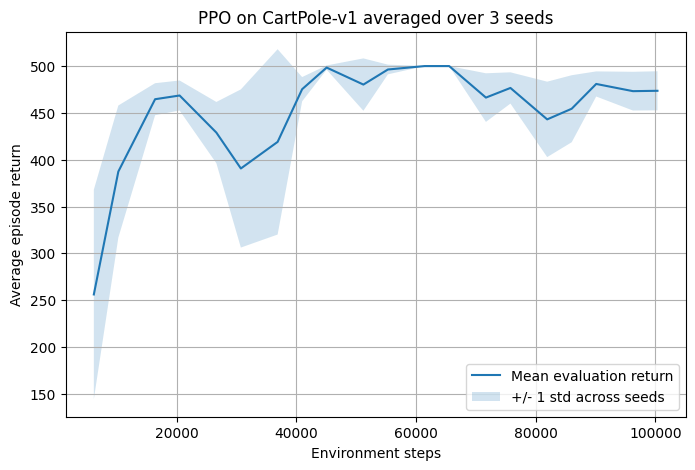

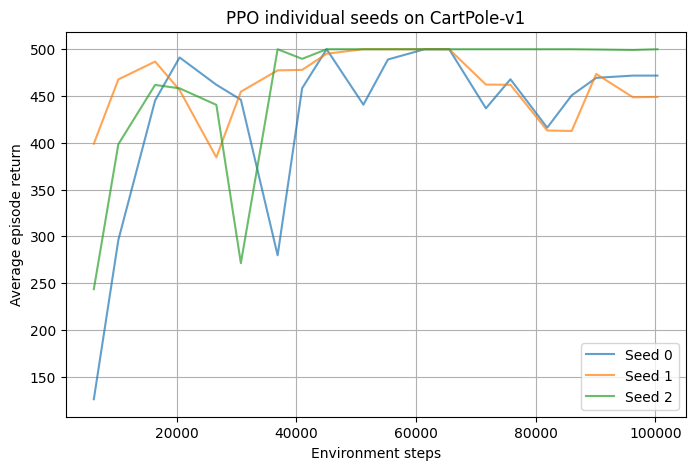

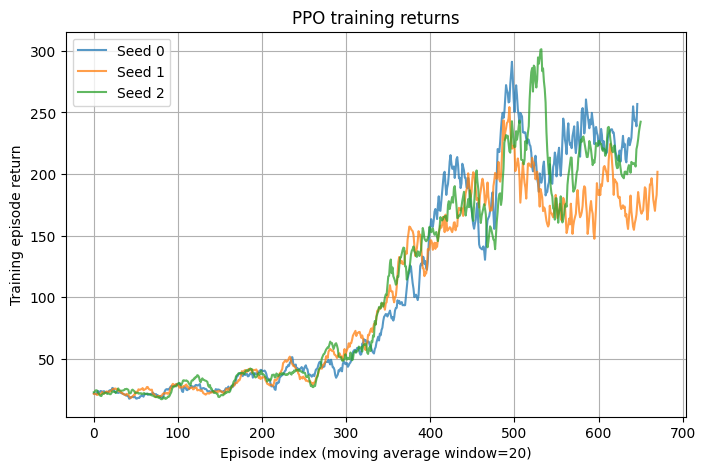

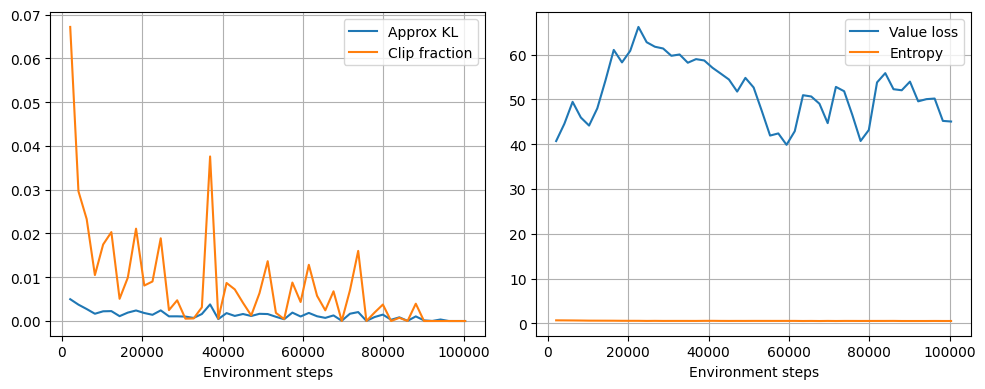

Final mean return: 473.60 +/- 20.86

####################################################################################################
Running PPO final experiment on Acrobot-v1
####################################################################################################

===== PPO training on Acrobot-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return= -500.00 | policy_loss=-0.0010 | value_loss=98.1438 | kl=0.00020 | clip_frac=0.000 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=  -86.90 | policy_loss=-0.0035 | value_loss=94.6454 | kl=0.00314 | clip_frac=0.020 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=  -81.00 | policy_loss=-0.0057 | value_loss=73.5427 | kl=0.00499 | clip_frac=0.041 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=  -86.20 | policy_loss=-0.0029 | value_loss=64.4954 | kl=0.00235 | clip_frac=0.023 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=  -97.80 | policy_loss=-0.0025 | value_loss=56.0008 | kl=0.00116 | clip_frac=0.008 | lr=1.89e-04
seed=

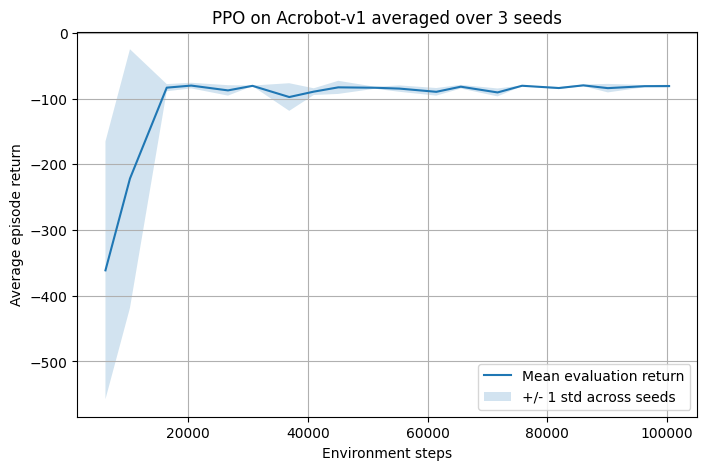

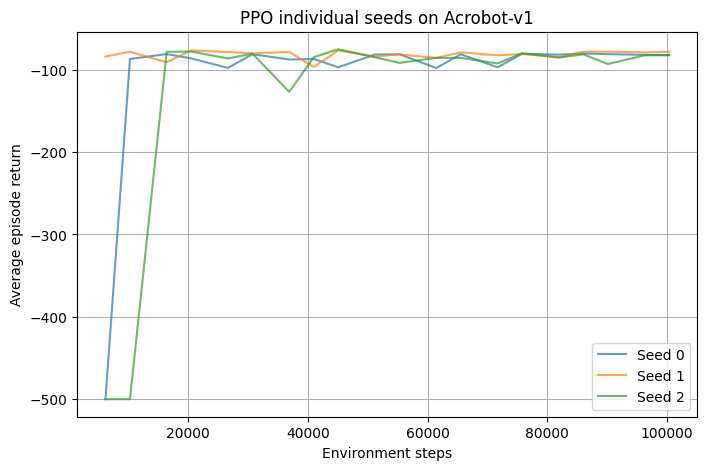

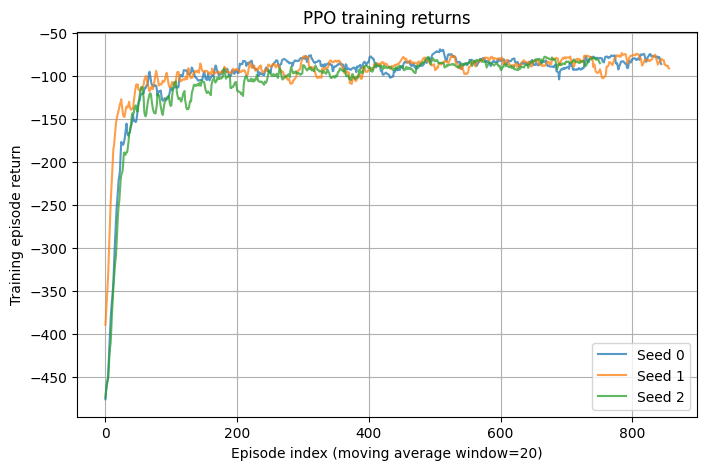

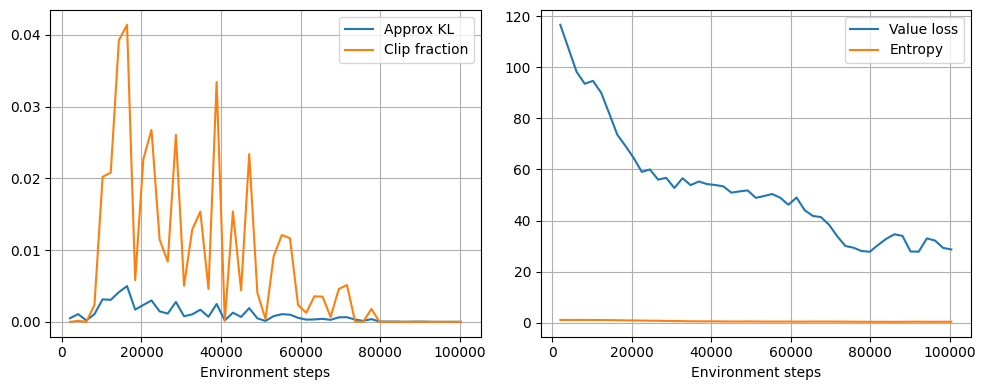

Final mean return: -80.93 +/- 1.94

####################################################################################################
Running PPO final experiment on Pendulum-v1
####################################################################################################

===== PPO training on Pendulum-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=-1092.40 | policy_loss=-0.0008 | value_loss=5759.3968 | kl=0.00086 | clip_frac=0.003 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=-1072.32 | policy_loss=-0.0012 | value_loss=4971.9605 | kl=0.00090 | clip_frac=0.004 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=-1078.94 | policy_loss=-0.0010 | value_loss=4783.3710 | kl=0.00128 | clip_frac=0.006 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=-1069.53 | policy_loss=-0.0019 | value_loss=4196.4237 | kl=0.00214 | clip_frac=0.015 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=-1080.56 | policy_loss=-0.0005 | value_loss=3506.3720 | kl=0.00042 | clip_frac=0.000 | lr=1.8

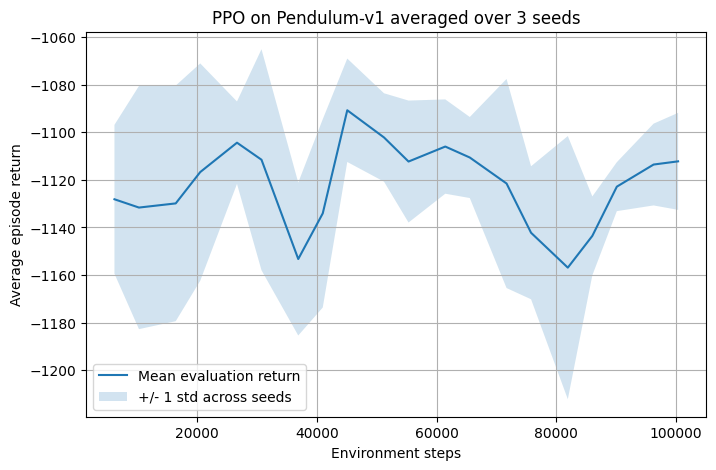

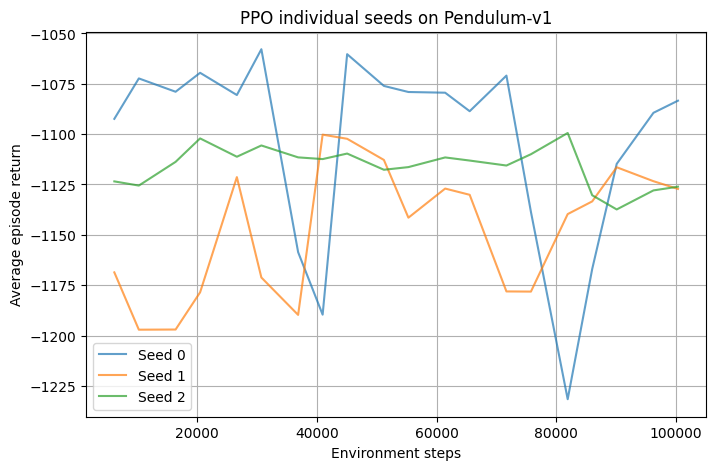

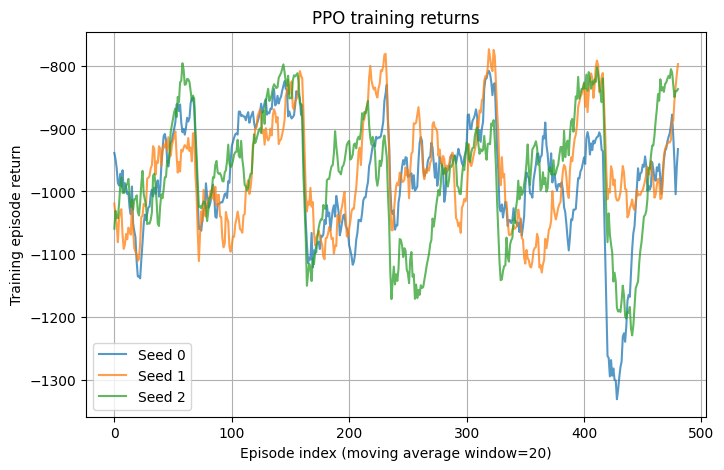

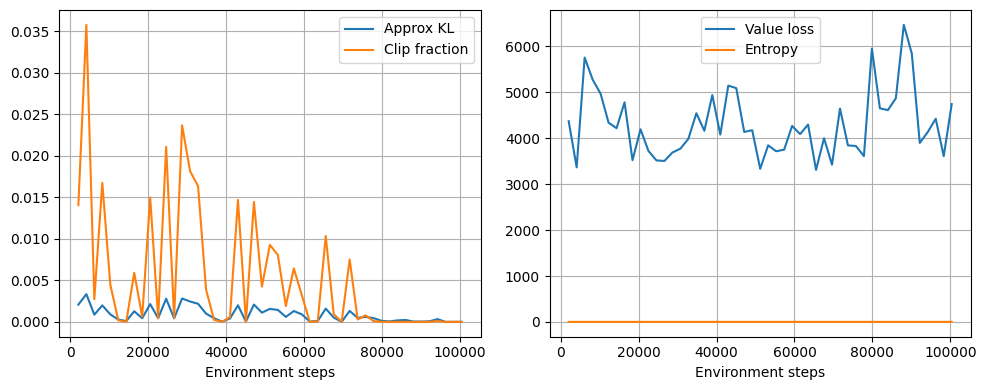

Final mean return: -1112.22 +/- 20.40


In [13]:
all_env_results = {}

for ENV_KEY in PPO_ENV_KEYS:
    ENV_NAME = ENVIRONMENTS[ENV_KEY]

    print("\n" + "#" * 100)
    print(f"Running PPO final experiment on {ENV_NAME}")
    print("#" * 100)

    env_result_dir = RESULTS_DIR / ENV_NAME
    env_result_dir.mkdir(parents=True, exist_ok=True)

    final_results = run_multiple_seeds(env_name=ENV_NAME, config=base_config, seeds=seeds)
    steps, eval_matrix = extract_eval_curves(final_results)
    mean, std = compute_statistics(eval_matrix)

    save_pickle(remove_models_from_results(final_results), env_result_dir / "final_results_raw.pkl")
    save_json(asdict(base_config), env_result_dir / "final_config.json")
    save_eval_curve_csv(steps, eval_matrix, mean, std, env_result_dir / "final_eval_curve.csv")

    for seed, result in zip(seeds, final_results):
        save_trained_model(result["model"], env_result_dir / f"ppo_actor_critic_seed_{seed}.pt")

    plot_eval_curve(
        steps,
        mean,
        std,
        title=f"PPO on {ENV_NAME} averaged over {len(seeds)} seeds",
        save_path=env_result_dir / "final_eval_curve.png",
    )
    plot_individual_seed_curves(
        steps,
        eval_matrix,
        title=f"PPO individual seeds on {ENV_NAME}",
        save_path=env_result_dir / "individual_seed_curves.png",
    )
    plot_rollout_returns(final_results, window=20, save_path=env_result_dir / "training_returns.png")
    plot_update_diagnostics(final_results[0], save_path=env_result_dir / "update_diagnostics_seed_0.png")

    all_env_results[ENV_NAME] = {
        "config": base_config,
        "results": final_results,
        "steps": steps,
        "eval_matrix": eval_matrix,
        "mean": mean,
        "std": std,
        "final_mean": float(mean[-1]),
        "final_std": float(std[-1]),
        "best_mean": float(np.max(mean)),
        "best_step": int(steps[int(np.argmax(mean))]),
    }

    print(
        f"Final mean return: {all_env_results[ENV_NAME]['final_mean']:.2f} +/- "
        f"{all_env_results[ENV_NAME]['final_std']:.2f}"
    )


# PPO Hyperparameter Sensitivity

Set `RUN_SENSITIVITY = True` for the report plots. By default this runs only on CartPole to keep the final pass practical; change `SENSITIVITY_ENV_KEY` if another environment is more useful for the PPO section.




===== PPO Learning rate sensitivity on CartPole-v1 =====

========== Learning rate: lr=0.0001 ==========

===== PPO training on CartPole-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=  177.30 | policy_loss=-0.0073 | value_loss=49.8959 | kl=0.00167 | clip_frac=0.007 | lr=9.59e-05
seed=0 | steps= 10240 | eval_return=  155.70 | policy_loss=-0.0055 | value_loss=57.2361 | kl=0.00111 | clip_frac=0.003 | lr=9.18e-05
seed=0 | steps= 16384 | eval_return=  229.10 | policy_loss=-0.0037 | value_loss=64.0443 | kl=0.00030 | clip_frac=0.000 | lr=8.57e-05
seed=0 | steps= 20480 | eval_return=  224.70 | policy_loss=-0.0019 | value_loss=69.3908 | kl=0.00017 | clip_frac=0.000 | lr=8.16e-05
seed=0 | steps= 26624 | eval_return=  492.70 | policy_loss=-0.0016 | value_loss=77.5119 | kl=0.00020 | clip_frac=0.000 | lr=7.54e-05
seed=0 | steps= 30720 | eval_return=  500.00 | policy_loss=-0.0042 | value_loss=72.3768 | kl=0.00057 | clip_frac=0.001 | lr=7.13e-05
seed=0 | steps= 36864 | eval_return=  497.00 |

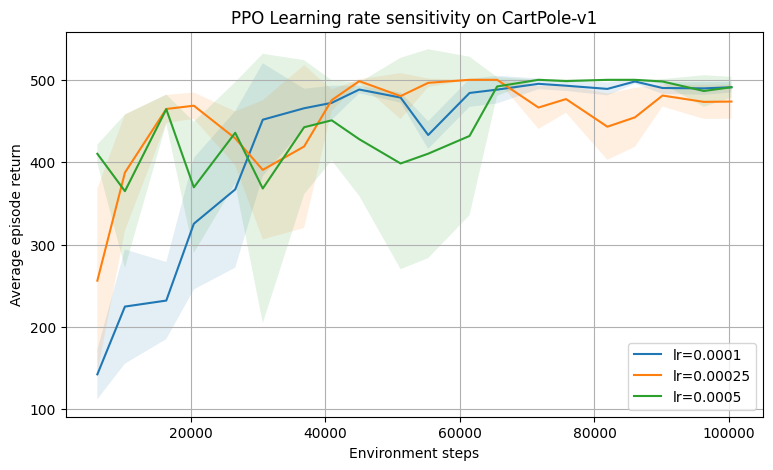



===== PPO Clip epsilon sensitivity on CartPole-v1 =====

========== Clip epsilon: clip_epsilon=0.1 ==========

===== PPO training on CartPole-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=   89.10 | policy_loss=-0.0061 | value_loss=37.7358 | kl=0.00124 | clip_frac=0.050 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=  171.80 | policy_loss=-0.0076 | value_loss=27.9268 | kl=0.00134 | clip_frac=0.056 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=  438.60 | policy_loss=-0.0056 | value_loss=44.2237 | kl=0.00095 | clip_frac=0.042 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=  450.20 | policy_loss=-0.0035 | value_loss=52.0516 | kl=0.00062 | clip_frac=0.023 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=  455.00 | policy_loss=-0.0037 | value_loss=60.4479 | kl=0.00056 | clip_frac=0.016 | lr=1.89e-04
seed=0 | steps= 30720 | eval_return=  460.80 | policy_loss=-0.0012 | value_loss=58.7108 | kl=0.00034 | clip_frac=0.006 | lr=1.78e-04
seed=0 | steps= 36864 | eval_return=  474

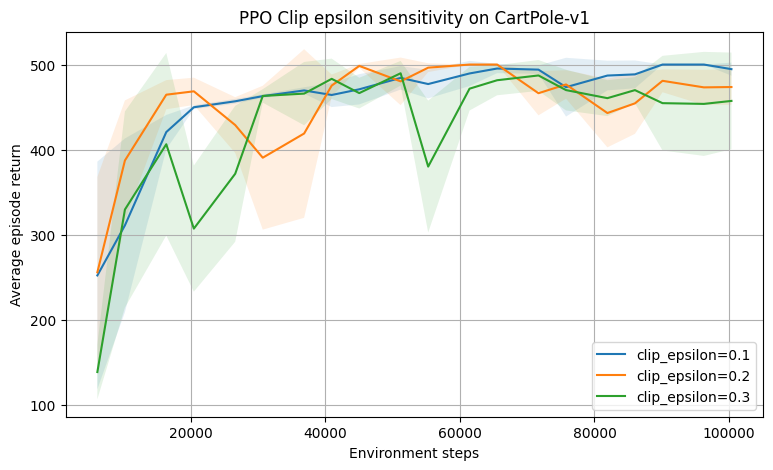



===== PPO Update epochs sensitivity on CartPole-v1 =====

========== Update epochs: num_epochs=4 ==========

===== PPO training on CartPole-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=  120.60 | policy_loss=-0.0061 | value_loss=48.8629 | kl=0.00141 | clip_frac=0.005 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=   94.30 | policy_loss=-0.0053 | value_loss=66.0166 | kl=0.00078 | clip_frac=0.001 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=  154.90 | policy_loss=-0.0029 | value_loss=63.8564 | kl=0.00020 | clip_frac=0.000 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=  179.70 | policy_loss=-0.0013 | value_loss=67.2243 | kl=0.00009 | clip_frac=0.000 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=  418.80 | policy_loss=-0.0040 | value_loss=70.2233 | kl=0.00084 | clip_frac=0.002 | lr=1.89e-04
seed=0 | steps= 30720 | eval_return=  499.90 | policy_loss=-0.0013 | value_loss=75.7168 | kl=0.00010 | clip_frac=0.000 | lr=1.78e-04
seed=0 | steps= 36864 | eval_return=  457.4

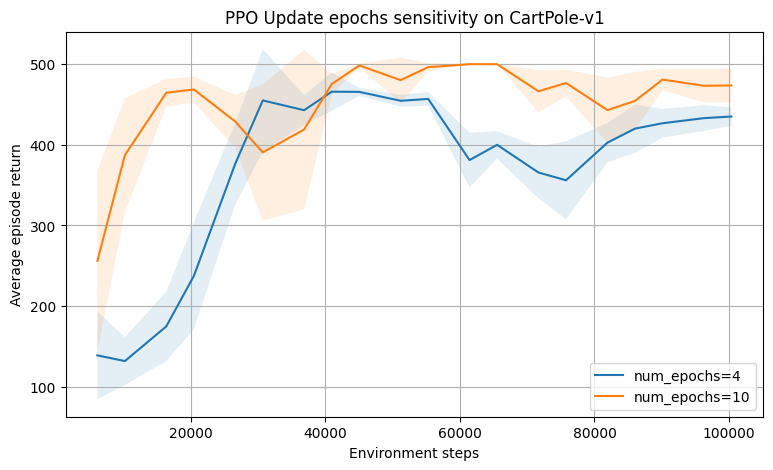



===== PPO Rollout actors sensitivity on CartPole-v1 =====

========== Rollout actors: num_envs=1, rollout_steps=2048 ==========

===== PPO training on CartPole-v1, seed 0 =====
seed=0 | steps=  6144 | eval_return=  339.80 | policy_loss=-0.0057 | value_loss=46.3341 | kl=0.00207 | clip_frac=0.012 | lr=2.40e-04
seed=0 | steps= 10240 | eval_return=  341.30 | policy_loss=-0.0077 | value_loss=51.2141 | kl=0.00157 | clip_frac=0.011 | lr=2.30e-04
seed=0 | steps= 16384 | eval_return=  482.90 | policy_loss=-0.0033 | value_loss=63.7993 | kl=0.00111 | clip_frac=0.004 | lr=2.14e-04
seed=0 | steps= 20480 | eval_return=  484.90 | policy_loss=-0.0050 | value_loss=62.3676 | kl=0.00221 | clip_frac=0.017 | lr=2.04e-04
seed=0 | steps= 26624 | eval_return=  494.90 | policy_loss=-0.0012 | value_loss=66.6824 | kl=0.00086 | clip_frac=0.001 | lr=1.89e-04
seed=0 | steps= 30720 | eval_return=  483.10 | policy_loss=-0.0010 | value_loss=62.5489 | kl=0.00131 | clip_frac=0.009 | lr=1.78e-04
seed=0 | steps= 36864 |

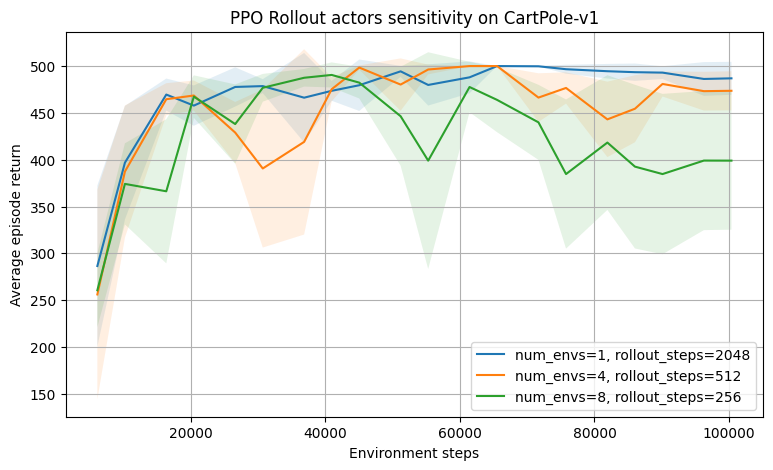

In [14]:
RUN_SENSITIVITY = True
SENSITIVITY_ENV_KEY = "cartpole"
SENSITIVITY_ENV_NAME = ENVIRONMENTS[SENSITIVITY_ENV_KEY]

if RUN_SENSITIVITY:
    env_result_dir = RESULTS_DIR / SENSITIVITY_ENV_NAME
    sensitivity_experiments = {
        "Learning rate": make_variation_configs(base_config, "lr", [1e-4, 2.5e-4, 5e-4]),
        "Clip epsilon": make_variation_configs(base_config, "clip_epsilon", [0.1, 0.2, 0.3]),
        "Update epochs": make_variation_configs(base_config, "num_epochs", [4, 10]),
    }

    # Keep the PPO update batch fixed while changing how many actors collect it.
    # Otherwise num_envs=8 would get four times as many samples per update as num_envs=1.
    rollout_batch_size = base_config.rollout_steps * base_config.num_envs
    actor_configs = {}
    for num_envs in [1, 4, 8]:
        if rollout_batch_size % num_envs != 0:
            raise ValueError(f"Cannot keep rollout batch size {rollout_batch_size} fixed with num_envs={num_envs}")
        rollout_steps = rollout_batch_size // num_envs
        actor_configs[f"num_envs={num_envs}, rollout_steps={rollout_steps}"] = make_config(
            base_config,
            num_envs=num_envs,
            rollout_steps=rollout_steps,
        )
    sensitivity_experiments["Rollout actors"] = actor_configs

    sensitivity_results = {}
    for experiment_name, configs in sensitivity_experiments.items():
        print(f"\n\n===== PPO {experiment_name} sensitivity on {SENSITIVITY_ENV_NAME} =====")
        results = run_hyperparameter_comparison(
            env_name=SENSITIVITY_ENV_NAME,
            experiment_name=experiment_name,
            configs=configs,
            seeds=seeds,
        )
        sensitivity_results[experiment_name] = results
        safe_experiment_name = experiment_name.lower().replace(" ", "_")

        save_pickle(
            {
                label: {
                    **{k: v for k, v in result.items() if k != "all_results"},
                    "config": asdict(result["config"]),
                    "all_results": remove_models_from_results(result["all_results"]),
                }
                for label, result in results.items()
            },
            env_result_dir / f"sensitivity_{safe_experiment_name}_raw.pkl",
        )

        summary = summarize_results(results)
        pd.DataFrame(summary).to_csv(env_result_dir / f"sensitivity_{safe_experiment_name}_summary.csv", index=False)

        for row in summary:
            print(
                f"{row['config']:35s} | final = {row['final_mean']:.2f} +/- "
                f"{row['final_std']:.2f} | best = {row['best_mean_during_training']:.2f}"
            )

        plot_hyperparameter_comparison(
            results,
            title=f"PPO {experiment_name} sensitivity on {SENSITIVITY_ENV_NAME}",
            save_path=env_result_dir / f"sensitivity_{safe_experiment_name}_curve.png",
        )
else:
    print("Sensitivity experiments skipped.")


# Compact Result Export

This optional export mirrors the small `.npz` files already in the project root, which can be convenient for cross-algorithm plotting in the report.


In [15]:
SAVE_DIR = Path("ppo_saved_results")
SAVE_DIR.mkdir(exist_ok=True)

if "all_env_results" not in globals() or not all_env_results:
    raise NameError("No final PPO environment results found. Run the final multi-environment cell first.")

for env_name, result in all_env_results.items():
    safe_env_name = env_name.replace("-", "_").replace("/", "_")
    save_name = f"ppo_final_{safe_env_name}_3seeds"

    np.savez_compressed(
        SAVE_DIR / f"{save_name}.npz",
        steps=np.asarray(result["steps"]),
        eval_matrix=result["eval_matrix"],
        mean=result["mean"],
        std=result["std"],
    )

    metadata = {
        "save_name": save_name,
        "env_name": env_name,
        "config": asdict(result["config"]),
        "num_seeds": len(seeds),
        "final_mean": result["final_mean"],
        "final_std": result["final_std"],
        "best_mean": result["best_mean"],
        "best_step": result["best_step"],
    }

    with open(SAVE_DIR / f"{save_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {env_name} arrays to: {SAVE_DIR / (save_name + '.npz')}")
    print(f"Saved {env_name} metadata to: {SAVE_DIR / (save_name + '_metadata.json')}")


Saved CartPole-v1 arrays to: ppo_saved_results/ppo_final_CartPole_v1_3seeds.npz
Saved CartPole-v1 metadata to: ppo_saved_results/ppo_final_CartPole_v1_3seeds_metadata.json
Saved Acrobot-v1 arrays to: ppo_saved_results/ppo_final_Acrobot_v1_3seeds.npz
Saved Acrobot-v1 metadata to: ppo_saved_results/ppo_final_Acrobot_v1_3seeds_metadata.json
Saved Pendulum-v1 arrays to: ppo_saved_results/ppo_final_Pendulum_v1_3seeds.npz
Saved Pendulum-v1 metadata to: ppo_saved_results/ppo_final_Pendulum_v1_3seeds_metadata.json
